In [1]:
# Pipeline to slice catalogue into volume limited redshift slices and compare LF estimates


import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack
from astropy.io import fits
#
# Specify regions to loop over
regions=('S','N')
#
# Read the enhanced BGS catalogue produced by Augment_BGS_cat.ipynb
dat=Table.read('BGS_Y3_Sep2025_2pc.fits')
print('Meta data stored with ths table:')
print(dat.meta)
#
# Check selection cuts agree with stored meta data of the sample we have read
Sel=ca.selection('S')
assert dat.meta['FAINT_S'] == Sel['faint'], f"Faint limits do not match: {dat.meta['FAINT_S']} != {Sel['faint']}"
assert dat.meta['BRIGHT_S'] == Sel['bright'], f"Bright limits do not match: {dat.meta['BRIGHT_S']} != {Sel['bright']}"
assert dat.meta['ZMAX_S'] == Sel['zmax'], f"Zmax do not match: {dat.meta['ZMAX_S']} != {Sel['zmax']}"
assert dat.meta['ZMIN_S'] == Sel['zmin'], f"Zmin do not match: {dat.meta['ZMIN_S']} != {Sel['zmin']}"
assert dat.meta['QEVOL_S'] == Sel['Qevol'], f"Qevol do not match: {dat.meta['QEVOL_S']} != {Sel['Qevol']}"
assert dat.meta['AREA_S'] == Sel['area'], f"Areas do not match: {dat.meta['AREA_S']} != {Sel['area']}"
assert dat.meta['F_RAN_S'] == Sel['f_ran'], f"f_ran do not match: {dat.meta['F_RAN_S']} != {Sel['f_ran']}"
assert dat.meta['COL_S'] == Sel['col'], f"Colours do not match: {dat.meta['COL_S']} != {Sel['col']}"
assert dat.meta['STYLE_S'] == Sel['style'], f"Styles do not match: {dat.meta['STYLE_S']} != {Sel['style']}"
Sel=ca.selection('N')
assert dat.meta['FAINT_N'] == Sel['faint'], f"Faint limits do not match: {dat.meta['FAINT_N']} != {Sel['faint']}"
assert dat.meta['BRIGHT_N'] == Sel['bright'], f"Bright limits do not match: {dat.meta['BRIGHT_N']} != {Sel['bright']}"
assert dat.meta['ZMAX_N'] == Sel['zmax'], f"Zmax do not match: {dat.meta['ZMAX_N']} != {Sel['zmax']}"
assert dat.meta['ZMIN_N'] == Sel['zmin'], f"Zmin do not match: {dat.meta['ZMIN_N']} != {Sel['zmin']}"
assert dat.meta['QEVOL_N'] == Sel['Qevol'], f"Qevol do not match: {dat.meta['QEVOL_N']} != {Sel['Qevol']}"
assert dat.meta['AREA_N'] == Sel['area'], f"Areas do not match: {dat.meta['AREA_N']} != {Sel['area']}"
assert dat.meta['F_RAN_N'] == Sel['f_ran'], f"f_ran do not match: {dat.meta['F_RAN_N']} != {Sel['f_ran']}"
assert dat.meta['COL_N'] == Sel['col'], f"Colours do not match: {dat.meta['COL_N']} != {Sel['col']}"
assert dat.meta['STYLE_N'] == Sel['style'], f"Styles do not match: {dat.meta['STYLE_N']} != {Sel['style']}"

# Check cosmology used matches with that used to create the catalogue
assert dat.meta['OM0'] == ca.cosmo.Om0, f"Omega_0 does not match: {dat.meta['OM0']} != {ca.cosmo.Om0}"
assert dat.meta['H0'] == ca.cosmo.H0.value, f"H_0 does not match: {dat.meta['H0']} != {ca.cosmo.H0.value}"
assert dat.meta['TCMB0'] == ca.cosmo.Tcmb0.value, f"Omega_0 does not match: {dat.meta['OM0']} != {ca.cosmo.Tcmb0.value}"

print('Statistics of the data in the table:')
dat.info('stats')
#Placeholders for additional columns to add to the tbale 
dat.add_column(Column(name='izbin', data=np.zeros(dat['Z'].size))) # redshift label bin
dat.add_column(Column(name='invollim', data=np.zeros(dat['Z'].size))) # flag if in the volume limited subset of this redshift bin
dat.add_column(Column(name='vollim', data=np.zeros(dat['Z'].size))) # the volume of this volume limited sample

Meta data stored with ths table:
OrderedDict([('EXTNAME', 'LSS'), ('QEVOL_N', 0.78), ('ZMAX_N', 0.6), ('ZMIN_N', 0.002), ('BRIGHT_N', 10.0), ('FAINT_N', 19.54), ('AREA_N', 0.09278121822233744), ('F_RAN_N', 0.02), ('COL_N', 'blue'), ('STYLE_N', 'dashed'), ('QEVOL_S', 0.78), ('ZMAX_S', 0.6), ('ZMIN_S', 0.002), ('BRIGHT_S', 10.0), ('FAINT_S', 19.5), ('AREA_S', 0.2067143725378028), ('F_RAN_S', 0.02), ('COL_S', 'red'), ('STYLE_S', 'solid'), ('H0', 100.0), ('TCMB0', 2.725), ('OM0', 0.313)])
Statistics of the data in the table:
<Table length=157047>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.49131e+12  3.96273e+16 3.96373e+16
                 Z     0.213642    0.104147    0.0020764     0.59977
             NTILE      2.42606     0.91577            1           5
                RA      183.204     91.4521  0.000223487         360
               DEC      22.0169      

In [2]:
# Read one the corresponding Y3 random (It is matched to the orginal clustering catalogue and not yet the cuts made to our sample
fpath='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/nonKP/BGS_BRIGHT_7_clustering.ran.fits'
ranfull=ca.Y3load_catalogues(fpath)
ranfull.info('stats')

#Random sample and apply all cuts from the start for a quick run through
Sel=ca.selection('N')# import North selection cuts  
smaskN= (ranfull['Z'] > Sel['zmin']) & (ranfull['Z'] < Sel['zmax']) & (np.random.rand(ranfull['Z'].size)<Sel['f_ran'])\
      & (ranfull['rmag'] < Sel['faint'])  & (ranfull['rmag'] > Sel['bright']) & (ranfull['reg']=='N') 
Sel=ca.selection('S') # import South selection cuts    
smaskS= (ranfull['Z'] > Sel['zmin']) & (ranfull['Z'] < Sel['zmax']) &(np.random.rand(ranfull['Z'].size)<Sel['f_ran']) \
      & (ranfull['rmag'] < Sel['faint'])  & (ranfull['rmag'] > Sel['bright']) & (ranfull['reg']=='S')
smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
ran=ranfull[smask]    
print('South sample size:',smaskS.sum())
print('North sample size:',smaskN.sum())
ran.info('stats')


<Table length=30890761>
      name           mean        std         min         max    
---------------- ----------- ----------- ----------- -----------
        TARGETID  3.2786e+17 2.48765e+12 3.27858e+17 3.27868e+17
              RA     182.362     93.1026 1.44426e-05         360
             DEC     22.0439     23.2156    -19.5674     79.2522
           NTILE     2.24559    0.944439           1           5
         PHOTSYS          --          --          --          --
FRAC_TLOBS_TILES    0.977861   0.0316573           0           1
               Z    0.213384    0.104274  0.00200098     0.59999
          WEIGHT     1.26497    0.755124           0     68.9124
      WEIGHT_SYS           1           0           1           1
     WEIGHT_COMP     1.29179    0.769686           1          69
    WEIGHT_ZFAIL     1.00127  0.00520768           1     1.19818
   TARGETID_DATA 3.96297e+16 2.48594e+12 3.96273e+16 3.96374e+16
    flux_g_dered     26.5728     94.3445    -72.8934     9805.88
 

In [3]:
# Set up jackknife region limits to equally split up the randoms provided
# and assign unique indices to each region for both data and randoms
njack_S=0
dat['ijack']=-999  # default to mean unassigned
ran['ijack']=-999  # default to mean unassigned
for reg in regions:
    regmask = (dat['reg']==reg)   
    ranregmask = (ran['reg']==reg)  
    print('Processing region ',reg)
    if (reg=='S'):
      # set up the RA and dec boundaries  
      njack_S,limits_S=ca.solve_jackknife_nonsq(ran[ranregmask], ndiv_ra=4, ndiv_dec=5, offset=275)
      # assign randoms to regions
      ca.set_jackknife(ran, ranregmask, limits_S, 0, njack_S)
      # assign data to the same regions
      ca.set_jackknife(dat, regmask, limits_S, 0, njack_S)
    else: 
      # set up the RA and dec boundaries   
      njack_N,limits_N=ca.solve_jackknife_nonsq(ran[ranregmask], ndiv_ra=3, ndiv_dec=3, offset=275)
      # assign randoms to regions
      ca.set_jackknife(ran, ranregmask, limits_N, njack_S, njack_N)
      # assign data to the same regions  
      ca.set_jackknife(dat, regmask, limits_N, njack_S, njack_N)
    

Processing region  S
length of data table: 427183
assigning 21360 objects to jackknife region 0
assigning 21360 objects to jackknife region 1
assigning 21360 objects to jackknife region 2
assigning 21360 objects to jackknife region 3
assigning 21359 objects to jackknife region 4
assigning 21360 objects to jackknife region 5
assigning 21360 objects to jackknife region 6
assigning 21360 objects to jackknife region 7
assigning 21360 objects to jackknife region 8
assigning 21360 objects to jackknife region 9
assigning 21360 objects to jackknife region 10
assigning 21360 objects to jackknife region 11
assigning 21360 objects to jackknife region 12
assigning 21359 objects to jackknife region 13
assigning 21360 objects to jackknife region 14
assigning 21360 objects to jackknife region 15
assigning 21359 objects to jackknife region 16
assigning 21360 objects to jackknife region 17
assigning 21360 objects to jackknife region 18
assigning 21360 objects to jackknife region 19
Attempting to assign

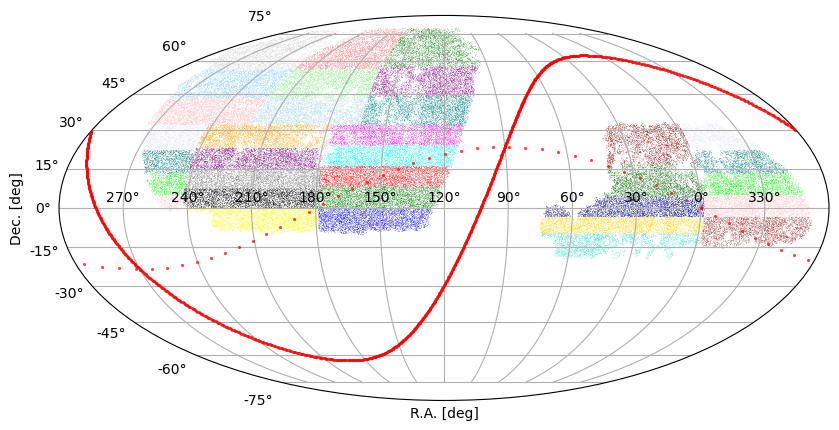

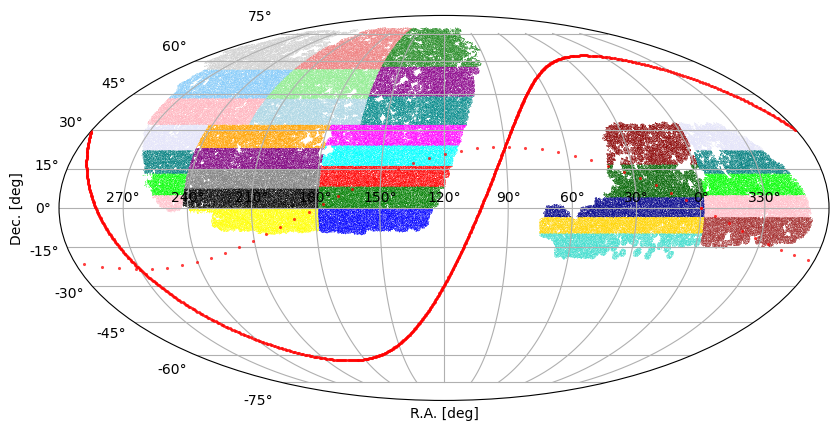

In [4]:
# Visualise the jackknife regions 'Black crosses indicate any unassigned objects'
ca.sky_plot_jack(dat)
ca.sky_plot_jack(ran)

redshift cuts: [0.002 0.05  0.1   0.2   0.3   0.4   0.5   0.6  ]


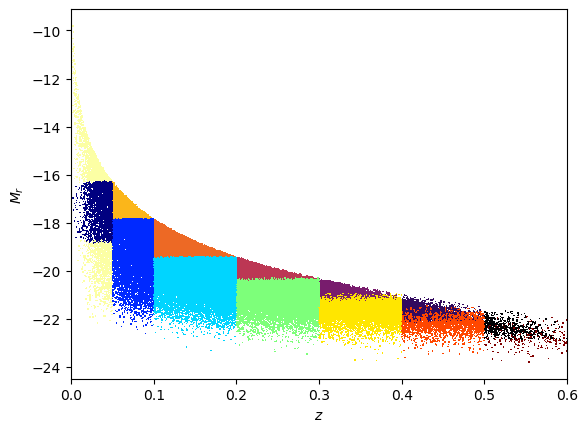

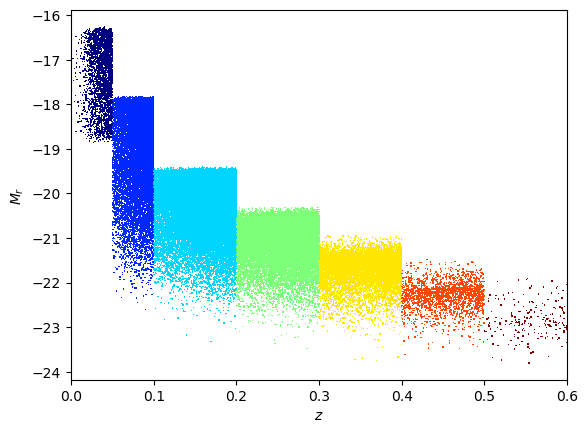

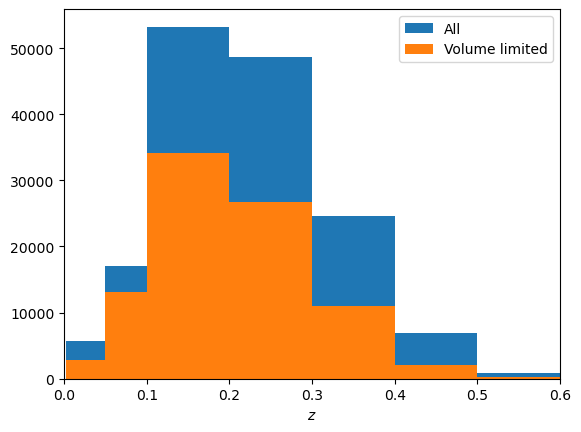

In [5]:
# Define redshift slices and volume limited samples within them


# set up the boundaries of the redshift slices with the lowest limit set by the already imposed Sel['zmin']
zbin_edges=np.linspace(0.0,0.6,num=7)
zbin_edges[0]=Sel['zmin']
zbin_edges= np.array([Sel['zmin'],0.05,0.1,0.2,0.3,0.4,0.5,0.6])
print('redshift cuts:',zbin_edges)


# Label according to redshift sample and compute correspnding volumes
ca.redshiftslices(dat,zbin_edges,regions,plotfrac=1.0)

0.02
      WEIGHT      
------------------
 2.256550428044354
               1.0
3.0157471145712957
 1.016132992740304
 3.036650589191499
1.0000838762318072
1.0113728812140126
2.2237119100168394
1.0039628462874104
1.0024242663262857
               ...
1.0009453066017069
1.4511149977029814
               1.0
 4.746859120006632
1.0006273884669965
1.0194078302912664
1.0015204548376304
1.0004666129403936
 1.005532230262759
1.0242506924370682
 1.000748098661453
Length = 3946 rows
      vollim      
------------------
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
               ...
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
1262884.9076648904
Length = 5646 rows
[0.00035736 0.00015837 0.0004776  ... 0.00015

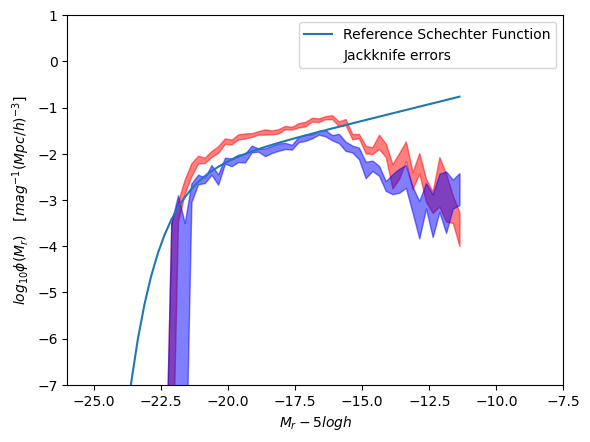

In [6]:
# Now we want to estimate LF's from each sample
#   *** Note Qevol comes into the definition of the samples and the absolute magnitudes
jzbin=2
mask=dat['izbin']==jzbin & dat['invollim'] #select in the volume limited subset of this redshift bin
log_phi_vmax,log_phi_low,log_phi_hi,magbins=ca.lumfun_vmax(dat[mask],regions,ratio=False,Vollim=True)

 

In [ ]:
#1/Vmax LF estimate
log_phi_vmax,log_phi_low,log_phi_hi,magbins=ca.lumfun_vmax(dat,regions,ratio=False)
#1/Vmax LF estimate
log_phi_vmax,log_phi_low,log_phi_hi,magbins=ca.lumfun_vmax(dat,regions,ratio=True)

## 